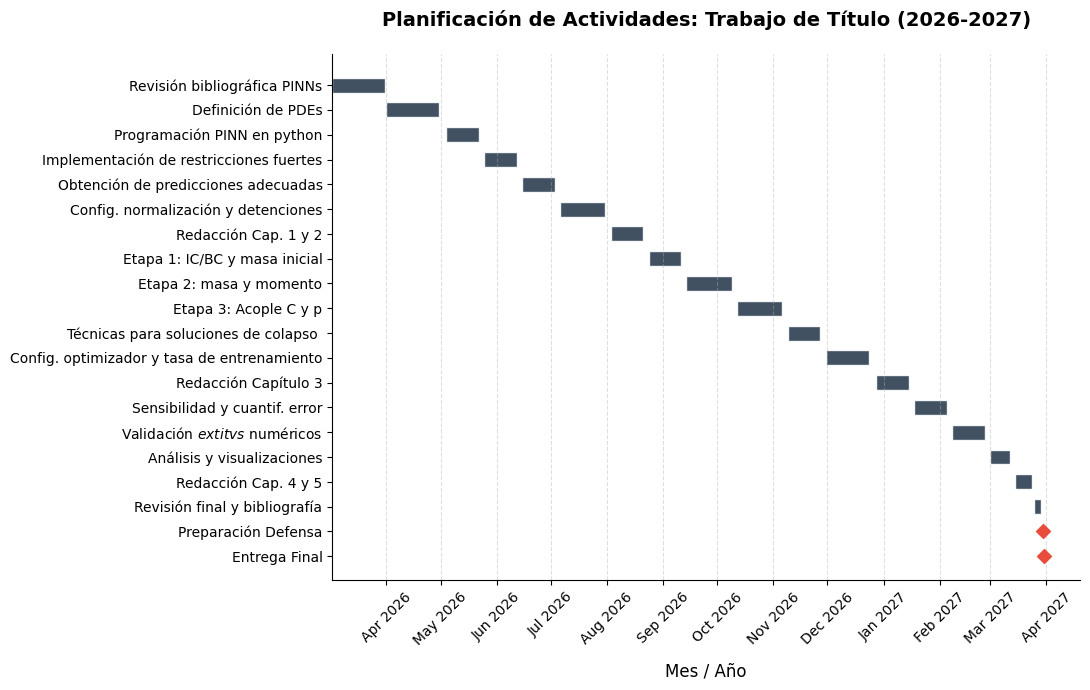

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Datos de tu planificación
data = [
    {"ID": 1, "Task": "Revisión bibliográfica PINNs", "Start": "2026-03-02", "End": "2026-03-31"},
    {"ID": 2, "Task": "Definición de PDEs", "Start": "2026-04-01", "End": "2026-04-30"},
    {"ID": 3, "Task": "Programación PINN en python", "Start": "2026-05-04", "End": "2026-05-22"},
    {"ID": 4, "Task": "Implementación de restricciones fuertes", "Start": "2026-05-25", "End": "2026-06-12"},
    {"ID": 5, "Task": "Obtención de predicciones adecuadas", "Start": "2026-06-15", "End": "2026-07-03"},
    {"ID": 6, "Task": "Config. normalización y detenciones", "Start": "2026-07-06", "End": "2026-07-31"},
    {"ID": 7, "Task": "Redacción Cap. 1 y 2", "Start": "2026-08-03", "End": "2026-08-21"},
    {"ID": 8, "Task": "Etapa 1: IC/BC y masa inicial", "Start": "2026-08-24", "End": "2026-09-11"},
    {"ID": 9, "Task": "Etapa 2: masa y momento", "Start": "2026-09-14", "End": "2026-10-09"},
    {"ID": 10, "Task": "Etapa 3: Acople C y p", "Start": "2026-10-12", "End": "2026-11-06"},
    {"ID": 11, "Task": "Técnicas para soluciones de colapso ", "Start": "2026-11-09", "End": "2026-11-27"},
    {"ID": 12, "Task": "Config. optimizador y tasa de entrenamiento", "Start": "2026-11-30", "End": "2026-12-24"},
    {"ID": 13, "Task": "Redacción Capítulo 3", "Start": "2026-12-28", "End": "2027-01-15"},
    {"ID": 14, "Task": "Sensibilidad y cuantif. error", "Start": "2027-01-18", "End": "2027-02-05"},
    {"ID": 15, "Task": "Validación $\textit{vs}$ numéricos", "Start": "2027-02-08", "End": "2027-02-26"},
    {"ID": 16, "Task": "Análisis y visualizaciones", "Start": "2027-03-01", "End": "2027-03-12"},
    {"ID": 17, "Task": "Redacción Cap. 4 y 5", "Start": "2027-03-15", "End": "2027-03-24"},
    {"ID": 18, "Task": "Revisión final y bibliografía", "Start": "2027-03-25", "End": "2027-03-29"},
    {"ID": 19, "Task": "Preparación Defensa", "Start": "2027-03-30", "End": "2027-03-30"},
    {"ID": 20, "Task": "Entrega Final", "Start": "2027-03-31", "End": "2027-03-31"}
]

df = pd.DataFrame(data)
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])
df = df.iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 7))

# Colores institucionales (Azul acero)
bar_color = '#2c3e50'

for i, task in df.iterrows():
    start = mdates.date2num(task['Start'])
    end = mdates.date2num(task['End'])
    
    # Si es un hito de un solo día (Defensa/Entrega), usamos un color distinto
    if task['Start'] == task['End']:
        # Aquí estaba el error. Cambiamos \"\" por ""
        ax.scatter(start, task['Task'], color='#e74c3c', marker='D', s=50, zorder=3, label='Hito' if i==19 else "")
    else:
        ax.barh(task['Task'], end - start, left=start, color=bar_color, edgecolor='white', height=0.6, alpha=0.9)

# Formateo de fechas
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Títulos y ejes
plt.title('Planificación de Actividades: Trabajo de Título (2026-2027)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Mes / Año', fontsize=12, labelpad=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Eliminar bordes innecesarios (estilo minimalista)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('carta_gantt_formal.png', dpi=400, bbox_inches='tight')
plt.show()